Question 1)
What is the fundamental idea behind ensemble techniques? How does bagging differ from boosting in terms of approach and objective?
Answer:

The fundamental idea of Ensemble Learning is to combine multiple machine learning models to achieve better accuracy and robustness than a single model.

Bagging:-

Models are trained independently and in parallel.
Uses bootstrap sampling.
Final prediction is obtained by voting (classification) or averaging (regression).
Main objective is to reduce variance and overfitting.


Boosting:-

Models are trained sequentially.
Each new model focuses on correcting previous errors.
Main objective is to reduce bias and improve accuracy.

**Question 2)**


**Explain how the Random Forest **Classifier reduces overfitting **compared to a single decision **tree.  Mention the role of two key** hyperparameters.    

Answer:-

A single Decision Tree can easily overfit the training data.

Random Forest reduces overfitting by:

Using multiple Decision Trees instead of one.
Applying bootstrap sampling.
Randomly selecting features at each split.

The final prediction is made through majority voting, making the model more stable.

Important Hyperparameters:-

1. n_estimators

Number of trees in the forest.
More trees generally improve performance.

2. max_depth

Controls maximum depth of trees.
Smaller depth reduces overfitting.


**Question 3)**


What is Stacking in ensemble learning? How does it differ from traditional bagging/boosting methods? Provide a simple example use case. **bold text**


Answer:

Stacking is an ensemble technique where multiple base models are trained and their predictions are used as input to another model called a meta-model.

Working
Train multiple models.
Collect predictions from each model.
Train a meta-model on these predictions.
Final prediction comes from the meta-model.

**Question 4**


What is the OOB Score in Random Forest, and why is it useful? How does it help in model evaluation without a separate validation set?
Answer:

OOB (Out-of-Bag) Score is an internal evaluation metric used in Random Forest.

During bootstrap sampling, some observations are not selected for training. These unused observations are called OOB samples.

The model predicts these OOB samples and calculates accuracy.

Advantages:-

No separate validation dataset required.


Saves training data.


Provides unbiased performance estimation.

**Question 5**


Compare AdaBoost and Gradient Boosting in terms of handling weak learners, weight adjustment mechanism, and typical use cases.


Answer:

AdaBoost:-

Mostly Decision Stumps.

Increases weights of misclassified samples.

Sequential.


Simpler.

Small datasets.

Gradient Boosting:-

Decision Trees.

Optimizes residual errors.

Sequential.

More Powerful.


Complex datasets.


**Question 6**


Why does CatBoost perform well on categorical features without requiring extensive preprocessing?


Answer:



CatBoost can directly handle categorical features without manual encoding.

It uses:

Ordered Target Encoding.

Efficient handling of categorical variables.

Built-in preprocessing.


Advantages


No extensive one-hot encoding required.


Reduces overfitting.


Faster and more accurate on categorical datasets.

In [1]:
# Q7. KNN Classifier Assignment: Wine Dataset Analysis with Optimization

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report

data = load_wine()

X_train,X_test,y_train,y_test = train_test_split(
    data.data,data.target,test_size=0.2,random_state=42
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

for metric in ['euclidean','manhattan']:

    knn = KNeighborsClassifier(
        n_neighbors=5,
        metric=metric
    )

    knn.fit(X_train,y_train)

    pred = knn.predict(X_test)

    print("\nMetric:",metric)
    print(classification_report(y_test,pred))


Metric: euclidean
              precision    recall  f1-score   support

           0       0.93      1.00      0.97        14
           1       1.00      0.86      0.92        14
           2       0.89      1.00      0.94         8

    accuracy                           0.94        36
   macro avg       0.94      0.95      0.94        36
weighted avg       0.95      0.94      0.94        36


Metric: manhattan
              precision    recall  f1-score   support

           0       0.93      1.00      0.97        14
           1       1.00      0.86      0.92        14
           2       0.89      1.00      0.94         8

    accuracy                           0.94        36
   macro avg       0.94      0.95      0.94        36
weighted avg       0.95      0.94      0.94        36



Explained Variance Ratio:
[9.82044672e-01 1.61764899e-02 1.55751075e-03 1.20931964e-04
 8.82724536e-05 6.64883951e-06 4.01713682e-06 8.22017197e-07
 3.44135279e-07 1.86018721e-07 6.99473205e-08 1.65908878e-08
 6.99641648e-09 4.78318305e-09 2.93549213e-09 1.41684926e-09
 8.29577731e-10 5.20405880e-10 4.08463983e-10 3.63313376e-10
 1.72849736e-10 1.27487508e-10 7.72682973e-11 6.28357715e-11
 3.57302295e-11 2.76396041e-11 8.14452259e-12 6.30211541e-12
 4.43666944e-12 1.55344680e-12]


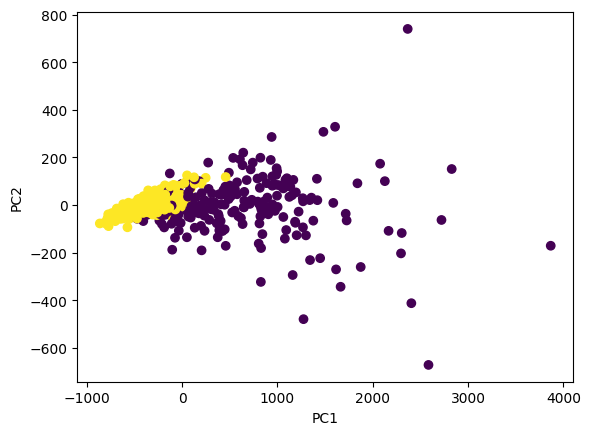

In [2]:
# Q8. PCA + KNN with Variance Analysis and Visualization

from sklearn.datasets import load_breast_cancer
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

data = load_breast_cancer()

pca = PCA()

pca.fit(data.data)

print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)

X_pca = PCA(n_components=2).fit_transform(data.data)

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=data.target
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [3]:
# Q9. KNN Regressor with Distance Metrics and K-Value Analysis

from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error

X,y = make_regression(
    n_samples=500,
    n_features=10,
    random_state=42
)

X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

for metric in ['euclidean','manhattan']:

    print("\nMetric:",metric)

    for k in [1,5,10,20,50]:

        model = KNeighborsRegressor(
            n_neighbors=k,
            metric=metric
        )

        model.fit(X_train,y_train)

        pred = model.predict(X_test)

        mse = mean_squared_error(y_test,pred)

        print("K =",k,"MSE =",mse)


Metric: euclidean
K = 1 MSE = 7081.692561017009
K = 5 MSE = 4600.793374160923
K = 10 MSE = 5078.056538872632
K = 20 MSE = 5890.608215277057
K = 50 MSE = 7793.423952005782

Metric: manhattan
K = 1 MSE = 9000.08959838139
K = 5 MSE = 5425.149185413367
K = 10 MSE = 5873.68486435603
K = 20 MSE = 6832.652078211148
K = 50 MSE = 8709.192297791566


In [4]:
# Q10. KNN with KD-Tree/Ball Tree and Missing Value Imputation

from sklearn.datasets import load_breast_cancer
from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import numpy as np

# Load dataset
data = load_breast_cancer()

X = data.data
y = data.target

# Create artificial missing values
X[0:20, 0] = np.nan
X[30:50, 2] = np.nan

# Imputation
imputer = KNNImputer(n_neighbors=5)
X = imputer.fit_transform(X)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# KD Tree
knn_kd = KNeighborsClassifier(
    n_neighbors=5,
    algorithm='kd_tree'
)

knn_kd.fit(X_train, y_train)

pred_kd = knn_kd.predict(X_test)

print("KD Tree Accuracy:",
      accuracy_score(y_test, pred_kd))

# Ball Tree
knn_ball = KNeighborsClassifier(
    n_neighbors=5,
    algorithm='ball_tree'
)

knn_ball.fit(X_train, y_train)

pred_ball = knn_ball.predict(X_test)

print("Ball Tree Accuracy:",
      accuracy_score(y_test, pred_ball))

KD Tree Accuracy: 0.956140350877193
Ball Tree Accuracy: 0.956140350877193
